# A single-unit incrementality demo

For one treated unit with a handful of treatment windows. We'll build a synthetic 
dataset with a treatment effect we've planted ourselves — so we know the right 
answer going in — estimate that effect back out with a counterfactual model, 
put the model through a backtest to see whether it's earned our trust, and 
finish by turning the estimate into the number that actually belongs in a media 
plan: cost per *incremental* click.

**The method** Fit a forecasting model on the periods where
nothing was happening — the *baseline* — and ask it to predict what would have
happened during the treatment windows if nothing had changed. The gap between that
prediction and what actually happened is the incremental effect. Do this per
window, aggregate across windows, and resample the windows to get a sense of how
much the answer could plausibly have varied.

### A quick glossary

A handful of terms carry specific meaning throughout this notebook — worth having
straight before the code starts flying.

- **Unit** — the single thing being measured. Here, one paid-media channel.
- **Bucket** — one row of the time series: one hour of data, in this case. The
  contract works at whatever granularity you hand it; this notebook happens to use
  hourly buckets.
- **Metric** — the number being measured in each bucket. Clicks, here.
- **Treatment window** (or just **window**) — a declared span of buckets during
  which the treatment was active — a media burst switched on, a promo running, a
  channel paused, depending on the design.
- **Baseline** — every bucket that isn't inside a window or its washout. This is
  what the forecasting model trains on.
- **Washout** — a buffer of buckets immediately before and after a window, excluded
  from both fitting and scoring because carryover effects make them neither cleanly
  treated nor cleanly untreated.
- **Counterfactual** — what the model predicts *would* have happened inside a
  window if nothing had changed. The thing we can never actually observe, and the
  entire reason this method exists.
- **Lift** — the estimated effect: actual minus counterfactual, expressed as a
  ratio and sign-resolved so a positive number always means the treatment helped.

In [1]:
# On Colab only: install the published package. Locally, `uv sync` has already done it.
# Called through subprocess rather than a `!pip` magic so that the paired .py file
# stays valid Python.
import importlib.util
import subprocess
import sys

if "google.colab" in sys.modules and importlib.util.find_spec("arjentic") is None:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "arjentic-incrementality"],
        check=True,
    )

In [2]:
# Prophet prints a banner on import and its sampler narrates every fit, neither of
# which belongs in a report. Absorb the banner here so the import below is quiet.
import contextlib
import io
import logging
import warnings

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").disabled = True
with contextlib.redirect_stderr(io.StringIO()), contextlib.redirect_stdout(io.StringIO()):
    import prophet  # noqa: F401

In [3]:
import dataclasses

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import transforms
import pandas as pd

from arjentic.incrementality import BaselineState, RunConfig, generate, run
from arjentic.incrementality.contracts import Role, validate
from arjentic.incrementality.diagnostics import backtest
from arjentic.incrementality.estimate import label_roles
from arjentic.incrementality.models import get_model

pd.set_option("display.float_format", "{:,.4f}".format)

In [4]:
# Chart styling. One place, so every figure reads as part of the same set.
# ! todo: move into a config file
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
SECONDARY = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
AXIS = "#c3c2b7"
ACTUAL = "#2a78d6"  # categorical slot 1
COUNTERFACTUAL = "#eb6834"  # categorical slot 2

plt.rcParams.update(
    {
        "figure.figsize": (11, 4),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": AXIS,
        "axes.labelcolor": SECONDARY,
        "axes.titlecolor": INK,
        "axes.titlesize": 12,
        "axes.titlelocation": "left",
        "axes.titlepad": 12,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": SECONDARY,
        "ytick.labelcolor": SECONDARY,
        "font.size": 10,
        "legend.frameon": False,
        "lines.linewidth": 1.6,
    }
)


def style(ax, title=None, ylabel=None):
    """Hairline recessive chrome: no top/right spines, horizontal grid only."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_linewidth(0.8)
    ax.grid(axis="x", visible=False)
    if title:
        ax.set_title(title)
    if ylabel:
        ax.set_ylabel(ylabel)
    return ax

## 1. Generate the dataset

Picture a paid-media channel that ran four short bursts over a 90-day stretch —
hourly click data, the usual weekly and daily rhythm, some noise, and a trend
drifting underneath it all. Inside those four bursts we've baked in a **20% lift**,
on purpose, so there's a right answer to check the method against later.

In [5]:
df, windows, truth = generate()

print(f"observations : {len(df):,} hourly buckets")
print(f"span         : {df['timestamp'].min()} -> {df['timestamp'].max()}")
print(f"planted effect: {truth['effect_size']:+.0%}")
windows

observations : 2,160 hourly buckets
span         : 2024-01-01 00:00:00+00:00 -> 2024-03-30 23:00:00+00:00
planted effect: +20%


,window_id,start,end
0,w0,2024-01-24 04:00:00+00:00,2024-01-24 10:00:00+00:00
1,w1,2024-02-07 14:00:00+00:00,2024-02-07 20:00:00+00:00
2,w2,2024-02-22 00:00:00+00:00,2024-02-22 06:00:00+00:00
3,w3,2024-03-07 10:00:00+00:00,2024-03-07 16:00:00+00:00


Before any of that data gets near a model, it passes through a contract check —
dtypes, nulls, duplicate timestamps, regular spacing, timezone-awareness, and a
check that every declared window actually falls inside the observed range. It's a
strict, unglamorous gate, and that's the point: everything downstream gets to
assume the data is well-formed and sorted, instead of defending against it at every
step.

In [6]:
observations, treatment_windows = validate(df, windows)
observations.head(3)

,unit_id,timestamp,value
0,unit_0,2024-01-01 00:00:00+00:00,70.6399
1,unit_0,2024-01-01 01:00:00+00:00,68.8064
2,unit_0,2024-01-01 02:00:00+00:00,75.6857


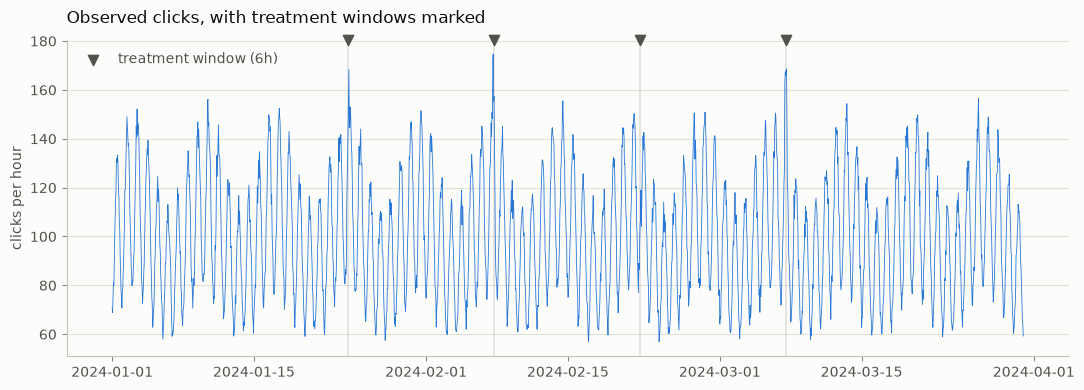

In [7]:
fig, ax = plt.subplots()
ax.plot(observations["timestamp"], observations["value"], color=ACTUAL, linewidth=0.6)
for _, window in treatment_windows.iterrows():
    ax.axvspan(window["start"], window["end"], color=MUTED, alpha=0.20, linewidth=0)

# Six hours is a quarter of a percent of this axis, so a shaded band alone is
# indistinguishable from a gridline. Mark each window on the top edge instead.
midpoints = treatment_windows["start"] + (
    treatment_windows["end"] - treatment_windows["start"]
) / 2
ax.scatter(
    midpoints,
    [1.0] * len(midpoints),
    marker="v",
    s=55,
    color=SECONDARY,
    transform=transforms.blended_transform_factory(ax.transData, ax.transAxes),
    clip_on=False,
    zorder=5,
    label="treatment window (6h)",
)

ax.legend(loc="upper left", labelcolor=SECONDARY)
style(ax, "Observed clicks, with treatment windows marked", "clicks per hour")
fig.tight_layout()

Squint all you like — you won't find the treatment effect in that chart. Six-hour
windows against ninety days of hourly data are a needle in a haystack, and that's
the normal case here, not a contrived one. It's exactly why this needs a model
instead of an eyeball: nobody is spotting a 20% bump by staring at a line chart.

## 2. Set up and run the experiment

Two choices in the config below quietly decide the sign and the honesty of
everything that follows, so they're worth pausing on rather than skimming past.

**`baseline_state`** answers a simple but easy-to-flub question: was the treatment
*on* or *off* outside the windows? Here the media only ran inside the four bursts,
so the baseline is `UNTREATED`. This one setting fixes the sign of the entire
estimate — get it backwards and you'll report a channel *hurting* performance when
it's helping, and the output will still look completely plausible. We declare it
rather than infer it for exactly that reason.

**`washout_before` / `washout_after`** carve out a buffer of buckets on either side
of every window, discarded from both fitting and scoring. Carryover means those
buckets are neither cleanly treated nor cleanly untreated, so counting them either
way would quietly bias the result. There's no default here on purpose — an
unstated washout is an assumption made by accident, and this method doesn't let you
make it by accident.

In [8]:
# Model parameters belong to the backend that reads them, so they are declared per
# backend rather than shared. Prophet's seasonality is pinned explicitly.
MODEL_PARAMS = {
    "prophet": {"daily_seasonality": True, "weekly_seasonality": True},
    "naive": {},
}

config = RunConfig(
    unit_id="unit_0",
    baseline_state=BaselineState.UNTREATED,
    washout_before=3,
    washout_after=6,
    primary_model="prophet",
    model_params=MODEL_PARAMS["prophet"],
    backtest_holdout_buckets=168,
    bootstrap_seed=42,
    bootstrap_resamples=2000,
)


def config_for(model_name):
    """The same declared experiment, run through a different backend."""
    return dataclasses.replace(
        config, primary_model=model_name, model_params=MODEL_PARAMS[model_name]
    )


config

RunConfig(unit_id='unit_0', baseline_state=<BaselineState.UNTREATED: 'untreated'>, washout_before=3, washout_after=6, primary_model='prophet', backtest_holdout_buckets=168, model_params={'daily_seasonality': True, 'weekly_seasonality': True}, bootstrap_seed=42, bootstrap_resamples=2000)

Notice that washout only gets handled once — every bucket gets tagged with a role
up front, and everything downstream just filters on it. The model fits on
`baseline`, the estimator scores `window`, and `washout` buckets are simply never
selected by either step. Nobody downstream has to remember washout exists.

In [9]:
labeled = label_roles(
    observations,
    treatment_windows,
    washout_before=config.washout_before,
    washout_after=config.washout_after,
)
labeled["role"].value_counts().rename("buckets").to_frame()

,buckets
role,
baseline,2100
washout,36
window,24


## 3. Results

In [10]:
result = run(df, windows, config)
result.per_window

,window_id,actual,counterfactual,buckets,lift
0,w0,840.1479,704.7847,6,0.1921
1,w1,918.4356,740.5169,6,0.2403
2,w2,603.1572,534.2269,6,0.1290
3,w3,982.3025,794.9798,6,0.2356


Notice that `actual` and `counterfactual` are summed across each window's buckets
*before* we divide. That's not incidental — averaging per-bucket ratios instead
would get noisy fast anywhere the counterfactual dips close to zero, since you'd be
dividing by small, jittery numbers one bucket at a time.

In [11]:
print(f"planted effect        : {truth['effect_size']:+.2%}")
print()
print(f"pooled lift           : {result.pooled_lift:+.2%}")
print(f"mean of window ratios : {result.mean_of_ratios_lift:+.2%}")
print(f"95% interval          : [{result.ci_lower:+.2%}, {result.ci_upper:+.2%}]")
print(f"interval from         : {result.ci_method}")
print(f"model                 : {result.model_name}")

planted effect        : +20.00%

pooled lift           : +20.53%
mean of window ratios : +19.92%
95% interval          : [+16.42%, +23.79%]
interval from         : bootstrap
model                 : prophet


Two numbers, two different questions. **Pooled** weights each window by its
volume, so a big burst counts for more than a small one — it's the number that
matches how the media budget was actually spent. **Mean-of-ratios** treats every
window as one vote, regardless of size. Neither is "more correct"; report both, and
if they disagree by a wide margin, that's a signal worth chasing down rather than
averaging away. The confidence interval below tracks the pooled figure, since
that's the quantity the cost-per-click math further down actually depends on.

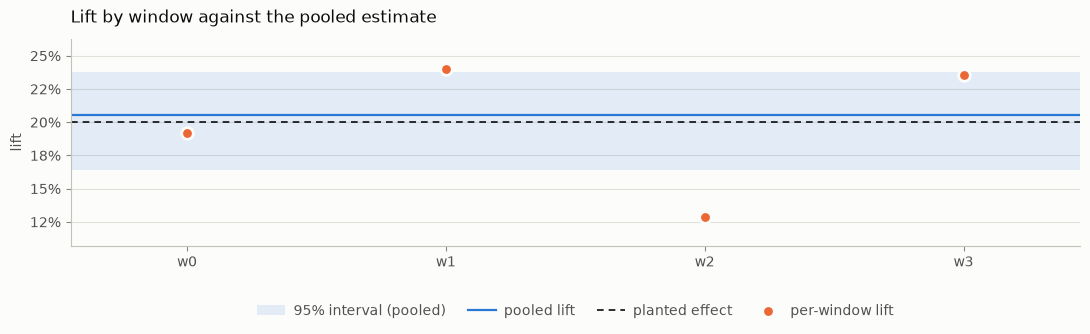

In [12]:
fig, ax = plt.subplots(figsize=(11, 3.6))
per_window = result.per_window

ax.axhspan(
    result.ci_lower,
    result.ci_upper,
    color=ACTUAL,
    alpha=0.12,
    linewidth=0,
    label="95% interval (pooled)",
)
ax.axhline(result.pooled_lift, color=ACTUAL, linewidth=1.6, label="pooled lift")
ax.axhline(
    truth["effect_size"],
    color=INK,
    linewidth=1.2,
    linestyle=(0, (4, 3)),
    label="planted effect",
)
ax.scatter(
    per_window["window_id"],
    per_window["lift"],
    s=70,
    color=COUNTERFACTUAL,
    zorder=3,
    edgecolor=SURFACE,
    linewidth=2,
    label="per-window lift",
)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.margins(x=0.15, y=0.20)
# Below the axis, not inside it: the per-window points reach both edges.
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncols=4,
    labelcolor=SECONDARY,
    handletextpad=0.6,
    columnspacing=1.6,
)
style(ax, "Lift by window against the pooled estimate", "lift")
fig.tight_layout()

Here's one window zoomed in: the dashed line and shaded band are what the model 
expected to see if nothing had changed, and the actual line climbing above them 
during the shaded window is the incremental volume this whole exercise is trying 
to measure.

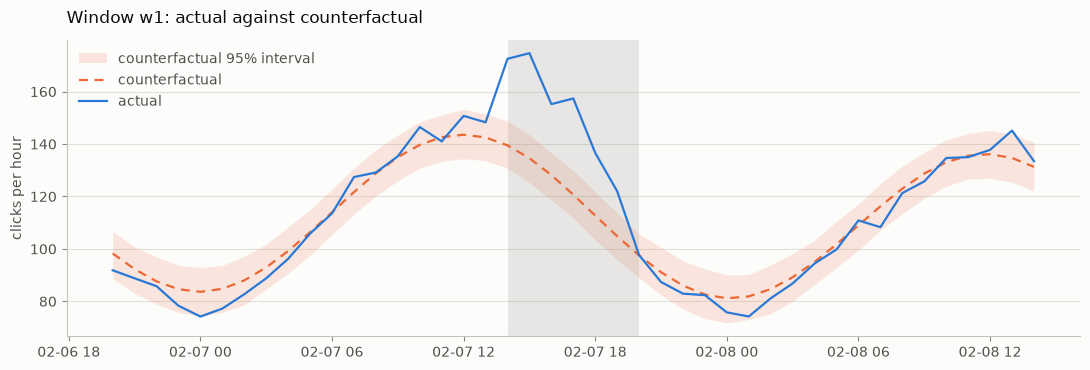

In [13]:
# todo: adapt for dashboard, allow interactive selection of windows

window = treatment_windows.iloc[1]
scored = labeled[labeled["window_id"] == window["window_id"]]

model = get_model(config.primary_model, **config.model_params)
model.fit(labeled[labeled["role"] == Role.BASELINE])

context = labeled[
    (labeled["timestamp"] >= window["start"] - pd.Timedelta(hours=18))
    & (labeled["timestamp"] <= window["end"] + pd.Timedelta(hours=18))
]
forecast = model.predict(context["timestamp"])

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.fill_between(
    forecast["timestamp"],
    forecast["lower"],
    forecast["upper"],
    color=COUNTERFACTUAL,
    alpha=0.15,
    linewidth=0,
    label="counterfactual 95% interval",
)
ax.plot(
    forecast["timestamp"],
    forecast["expected"],
    color=COUNTERFACTUAL,
    linestyle=(0, (4, 3)),
    label="counterfactual",
)
ax.plot(context["timestamp"], context["value"], color=ACTUAL, label="actual")
ax.axvspan(window["start"], window["end"], color=MUTED, alpha=0.18, linewidth=0)

ax.legend(loc="upper left", labelcolor=SECONDARY)
style(ax, f"Window {window['window_id']}: actual against counterfactual", "clicks per hour")
fig.tight_layout()

## 4. Validate the Counterfactual model

Everything above rests on one assumption: that the counterfactual is credible. So
before we lean on it, let's test it — hold out a chunk of *baseline* buckets the
model has never seen, refit without them, and check how well it predicts them back.
On live data, with no planted answer to check against, this is the only validation
you get.

One detail matters more than it looks like it should: the holdout comes from the
**middle** of the baseline, not the tail. The estimator always fits baseline on
both sides of a window and predicts the gap in between — it interpolates. A holdout
at the end of the series would test *extrapolation* instead, a strictly harder task
the model is never actually asked to perform, and the backtest would unfairly make
it look worse than it is.

In [14]:
# todo: validate backtest method
# todo: validate bias and handling
# todo: visualize the backtest, display results in dashboard

rows = []
for model_name in ("naive", "prophet"):
    diagnostic = backtest(df, windows, config_for(model_name))
    rows.append(
        {
            "model": diagnostic.model_name,
            "coverage": diagnostic.coverage,
            "nominal": diagnostic.nominal_coverage,
            "MAE": diagnostic.mae,
            "bias": diagnostic.bias,
            "relative bias": diagnostic.relative_bias,
        }
    )
pd.DataFrame(rows).set_index("model")

,coverage,nominal,MAE,bias,relative bias
model,,,,,
naive,0.9107,0.9500,2.2372,-0.1905,-0.0019
prophet,0.9583,0.9500,3.5965,-0.1265,-0.0013


Three numbers come out of this, and each is answering a different question.

- **Coverage**, checked against the nominal 95%, tells you whether the prediction
  interval is telling the truth. This matters most for single-window designs, where
  the reported confidence interval is built directly from these same bounds.
- **MAE** is just the size of a typical miss — useful, but it can't tell you *which
  direction* the model tends to be wrong.
- **Relative bias** is the one to actually worry about, because it's the one that
  bleeds straight into the answer. A counterfactual running 2% low inflates the
  lift estimate by roughly 2 points — nearly one-for-one. MAE can't tell that apart
  from harmless symmetric noise, which mostly cancels out across a window. Bias is
  why we report it separately instead of letting MAE speak for both.

A word on `naive`: it's nothing more than a day-of-week × hour-of-day average. It's
here partly to keep the model interface honest — if the naive backend can't plug
into the same protocol as Prophet, the abstraction is wrong — and partly as a gut
check. If a fancier model can't beat a groupby, that's worth knowing before you put
it in front of a client.

In [15]:
comparison = []
for model_name in ("naive", "prophet"):
    alternative = run(df, windows, config_for(model_name))
    comparison.append(
        {
            "model": alternative.model_name,
            "pooled lift": alternative.pooled_lift,
            "CI low": alternative.ci_lower,
            "CI high": alternative.ci_upper,
            "width": alternative.ci_upper - alternative.ci_lower,
        }
    )
pd.DataFrame(comparison).set_index("model")

,pooled lift,CI low,CI high,width
model,,,,
naive,0.2054,0.1945,0.2139,0.0194
prophet,0.2053,0.1642,0.2379,0.0737


Two models that share almost no machinery landing on roughly the same answer is
about as reassuring as this kind of check gets — it's evidence the *pipeline* found
the effect, not that one model happened to hallucinate it. Prophet's interval comes
out wider, and that's honest: its per-window counterfactuals disagree with each
other more than the naive model's do, and resampling across windows is exactly what
surfaces that disagreement.

## 5. Business Impacts

Say the four bursts cost **$18,000** in media. Whatever platform ran that spend will
happily hand you a cost-per-click calculated against *every* click that occurred
while the campaign was live — and most of those clicks would have shown up anyway,
with or without the spend. That "would have shown up anyway" volume is precisely
what the counterfactual has been estimating this whole time.

In [16]:
# todo: check this reasoning
# todo: make interactive on dashboard

MEDIA_SPEND = 18_000.0

clicks_during = result.per_window["actual"].sum()
counterfactual_clicks = result.per_window["counterfactual"].sum()
incremental = clicks_during - counterfactual_clicks

reported_cpc = MEDIA_SPEND / clicks_during
effective_cpc = MEDIA_SPEND / incremental

# Lift maps to incremental volume, so the interval carries straight through --
# inverted, because a higher lift means a cheaper incremental click.
effective_cpc_low = MEDIA_SPEND / (result.ci_upper * counterfactual_clicks)
effective_cpc_high = MEDIA_SPEND / (result.ci_lower * counterfactual_clicks)

print(f"media spend                : ${MEDIA_SPEND:,.0f}")
print(f"clicks while media ran     : {clicks_during:,.0f}")
print(f"of which incremental       : {incremental:,.0f}  ({incremental / clicks_during:.1%})")
print()
print(f"reported CPC               : ${reported_cpc:,.2f}")
print(f"effective CPC              : ${effective_cpc:,.2f}")
print(f"  95% interval             : ${effective_cpc_low:,.2f} - ${effective_cpc_high:,.2f}")
print()
print(f"reported CPC understates cost per incremental click by {effective_cpc / reported_cpc:.1f}x")

media spend                : $18,000
clicks while media ran     : 3,344
of which incremental       : 570  (17.0%)

reported CPC               : $5.38
effective CPC              : $31.60
  95% interval             : $27.27 - $39.52

reported CPC understates cost per incremental click by 5.9x


That multiple is the entire argument for running a test like this in the first
place. Judged on reported CPC, the channel looks several times more efficient than
it really is, because the denominator is stuffed with clicks the business was
getting for free anyway. The effective CPC is the number to hold up against a
margin or a target acquisition cost — the reported one will just get you a nicer
story.

## 6. Notes

No method write-up is complete without an honest look at where it bends. Here's
where this one does.

**The interval runs a bit optimistic.** We measured this directly: across window
counts from 2 to 12, the percentile bootstrap contained the true effect somewhere
between 73% and 87% of the time, against a nominal 95%. More windows didn't fix
it — the interval narrows roughly with the square root of the window count, while
the systematic forecast misfit underneath it doesn't shrink at all. With only two
windows, it can collapse to almost nothing. Treat these bounds as a useful
approximation rather than a courtroom-grade confidence interval, and be suspicious
of any result whose interval barely edges past zero.

**A single short window is fragile in a way that's easy to miss.** We held the
whole design fixed and moved just *where* one six-hour window landed — nothing
else — and watched the error swing from +8.1 to −6.0 percentage points, with barely
a point of scatter within any one position. That's local seasonality the model is
misreading, not noise, and a single short window has nothing else to average it
against. Several scattered windows aren't a nice-to-have here; they're what makes
the estimate trustworthy at all. Single-window designs are still fully supported —
the interval just comes from forecast uncertainty instead of resampling, and the
`ci_method` field on the result tells you which one you got.

**Passing the backtest validates the forecast, not the causal claim.** This one is
worth sitting with. The backtest only ever checks whether the model can predict
*untreated* buckets — it has no way to see a promotion, a price change, or a
competitor's outage that happened to land inside a treatment window, because the
counterfactual *under* treatment is unobservable by definition. Closing that gap is
a job for experimental design — placing windows so they're uncorrelated with
everything else going on — and no diagnostic will ever do it for you.

**What this notebook deliberately leaves out:** donor units and multi-unit designs,
geo holdouts, placebo tests, and the data-cleaning work that real-world data always
demands. The contract here assumes clean input and only enforces structure. Field
data tends to show up with gaps, duplicated rows from an upstream join gone
sideways, and timezone-naive timestamps that quietly mean local time — none of
which this walkthrough tries to solve.